In [1]:
from utils.paths import DATABASE_DIR,RAW_DIR,PREDICTIONS_DIR
from models_scripts.gp_workflow import ExperimentalGPApproach

from data.data_loading import load_table
from data.processing import merge_data, filter_by_wavelength
from data.splitting import DataSplitter
from data.preprocessing import prepare_train_test
from data.Descriptors import AlloyDescriptorCalculator
from evaluation.evaluation import compute_permutation_importance, importance_to_df

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load data
1. Experimental data
2. Resistivity calculation using ANN

In [8]:
df_optical = load_table(DATABASE_DIR / "Ternary_round1.db", "Optical_properties")
df_comp = load_table(DATABASE_DIR / "Ternary_round1.db", "compositions")
df_resis_ANN = load_table(DATABASE_DIR / "Ternary_round1.db", "ANN_resistivity")
# --- Merge ---
df_merged = merge_data(df_optical, df_comp) # Delete the pure elements
df_merged = df_merged[~df_merged["ID"].isin([29, 30, 31])]
# --- Filter ---
tern_1550 = filter_by_wavelength(df_merged, 1552.0)
tern_1550 = tern_1550.reset_index(drop=True)
tern_1550 = merge_data(tern_1550, df_resis_ANN[['ID','resistivity']])
# All space
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


In [9]:
df_merged.head()

,wavelength_nm,e1,e2,ID,Cu,Ni,Al
0,210,-1.388275,3.185155,1,0.95,0.05,0.0
1,211,-1.518159,3.189474,1,0.95,0.05,0.0
2,212,-1.640196,3.222080,1,0.95,0.05,0.0
3,213,-1.749701,3.277913,1,0.95,0.05,0.0
4,214,-1.843735,3.352174,1,0.95,0.05,0.0


splitting method selection based on the composition
1. Radom splitting
2. CLuster-based splitting

In [18]:
X = tern_1550[['Cu','Ni','Al','resistivity']].copy()
y = tern_1550['e2'].copy()

splitter = DataSplitter(
    test_size=0.2,
    random_state=42,
    split_method="cluster",
    n_clusters=6
)

split_dict = splitter.split(X, y)

Load the descriptors

In [19]:
calc = AlloyDescriptorCalculator()
descriptor_spec = {
    "atomic_radius": ["avg","mismatch"],
    "metallic_radius": ["avg","mismatch"],
    "electronegativity_pauling": ["avg","mismatch"],
    "electronegativity_allen": ["avg","mismatch"],
    "valence_electrons": ["avg","mismatch"],
    "density": ["avg","mismatch"],
    "electron_affinity": ["avg","mismatch"],
    "ionization_energy_1": ["avg","mismatch"],
    "ionization_energy_2": ["avg","mismatch"],
    "valence_s": ["avg","mismatch"],
    "valence_d": ["avg","mismatch"]
}

x_train = calc.transform(split_dict['X_train'], descriptor_spec=descriptor_spec, include_entropy=True)
x_test = calc.transform(split_dict['X_test'], descriptor_spec=descriptor_spec, include_entropy=True)

In [24]:
y_train = split_dict['y_train']
y_test = split_dict['y_test']

Gaussian Process mean  = 0

In [25]:
gp_exp = ExperimentalGPApproach(
    random_state=42,
    n_splits=5,
    scoring="r2",
    n_restarts_optimizer=5,
)

results = gp_exp.fit_and_evaluate(
    X_train=x_train,
    y_train=y_train,
    X_test=x_test,
    y_test=y_test,
)

model = gp_exp.model_

print("Best CV score:", results["best_score_cv"])
print("Best params:")
print(results["best_params"])
print("Train metrics:", results["train_metrics"])
print("Test metrics:", results["test_metrics"])

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-

...

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, g

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=Mi

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


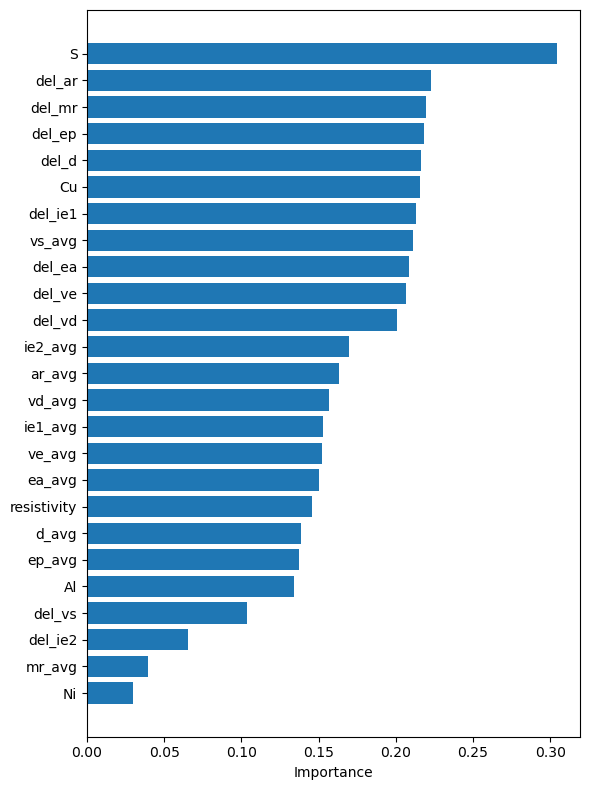

In [26]:
feature_names = x_test.columns

imp = compute_permutation_importance(model, x_test, y_test)
df_imp = importance_to_df(imp, feature_names)


plt.figure(figsize=(6,8))
plt.barh(df_imp["feature"], df_imp["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [2]:
df_wave = pd.read_csv(PREDICTIONS_DIR/"GP-Experiments/GP_wavelength_r2_partial.csv")

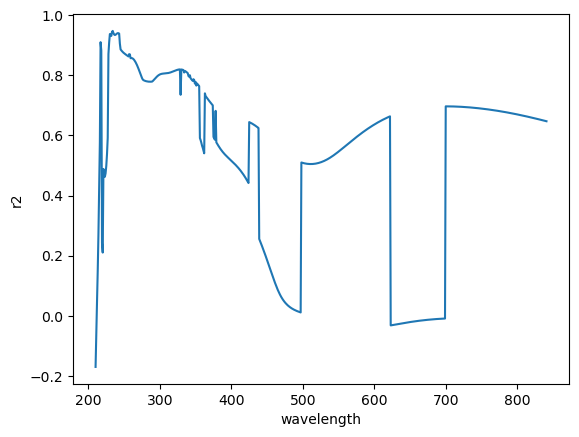

In [12]:
import matplotlib.pyplot as plt

plt.plot(df_wave['wavelength'], df_wave['r2'])
plt.xlabel('wavelength')
plt.ylabel('r2')
plt.show()